In [94]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, balanced_accuracy_score
import seaborn as sns
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Set device - DirectML for AMD GPU support on Windows
try:
    import torch_directml
    device = torch_directml.device()
    print(f"Using device: DirectML (AMD GPU)")
    print(f"DirectML device name: {torch_directml.device_name(0)}")
except ImportError:
    print("torch-directml not found. Install with: pip install torch-directml")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Falling back to: {device}")
except Exception as e:
    print(f"DirectML initialization failed: {e}")
    device = torch.device('cpu')
    print(f"Falling back to CPU")

Using device: DirectML (AMD GPU)
DirectML device name: AMD Radeon RX 6800 


In [95]:
# --- Dataset Class ---
class SharkFinDataset(Dataset):
    """Custom Dataset for shark fin fluorescence time-series data"""
    def __init__(self, features, labels, augment=False):
        self.features = torch.FloatTensor(features)
        self.labels = torch.LongTensor(labels)
        self.augment = augment
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        x = self.features[idx]
        y = self.labels[idx]

        if self.augment:
            # Small random noise
            noise = 0.01 * torch.randn_like(x)
            # Random scaling
            scale = 1 + 0.05 * torch.randn(1)
            x = x * scale + noise

            # Random horizontal shifts
            max_shift = 3
            shift = np.random.randint(-max_shift, max_shift + 1)
            if shift != 0:
                x = torch.roll(x, shifts=shift, dims=-1)
        
        return x, y

In [96]:
# --- TCN Model Architecture ---
class CausalConv1d(nn.Module):
    """Causal 1D convolution with weight normalization"""
    def __init__(self, in_channels, out_channels, kernel_size, dilation=1):
        super(CausalConv1d, self).__init__()
        self.padding = (kernel_size - 1) * dilation
        self.conv = nn.utils.weight_norm(
            nn.Conv1d(in_channels, out_channels, kernel_size, 
                     padding=self.padding, dilation=dilation)
        )
    
    def forward(self, x):
        x = self.conv(x)
        # Remove future information (causal)
        if self.padding > 0:
            x = x[:, :, :-self.padding]
        return x

class TemporalBlock(nn.Module):
    """Temporal block with residual connections"""
    def __init__(self, n_inputs, n_outputs, kernel_size, dilation, dropout=0.2):
        super(TemporalBlock, self).__init__()
        
        self.conv1 = CausalConv1d(n_inputs, n_outputs, kernel_size, dilation)
        self.bn1 = nn.BatchNorm1d(n_outputs)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)
        
        self.conv2 = CausalConv1d(n_outputs, n_outputs, kernel_size, dilation)
        self.bn2 = nn.BatchNorm1d(n_outputs)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)
        
        self.net = nn.Sequential(
            self.conv1, self.bn1, self.relu1, self.dropout1,
            self.conv2, self.bn2, self.relu2, self.dropout2
        )
        
        # Residual connection
        self.downsample = nn.Conv1d(n_inputs, n_outputs, 1) if n_inputs != n_outputs else None
        self.relu = nn.ReLU()
    
    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)

class TemporalConvNet(nn.Module):
    """Temporal Convolutional Network for time-series classification"""
    def __init__(self, num_inputs, num_channels, num_classes, kernel_size=3, dropout=0.2):
        super(TemporalConvNet, self).__init__()
        layers = []
        num_levels = len(num_channels)
        
        for i in range(num_levels):
            dilation_size = 2 ** i
            in_channels = num_inputs if i == 0 else num_channels[i-1]
            out_channels = num_channels[i]
            layers.append(
                TemporalBlock(in_channels, out_channels, kernel_size, 
                            dilation_size, dropout)
            )
        
        self.network = nn.Sequential(*layers)
        self.fc = nn.Linear(num_channels[-1], num_classes)
    
    def forward(self, x):
        # x shape: (batch, features, seq_len)
        y = self.network(x)
        # Global average pooling
        y = torch.mean(y, dim=2)
        return self.fc(y)

In [97]:
# --- Training and Evaluation Functions ---
def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    return total_loss / len(train_loader), 100. * correct / total

def evaluate(model, data_loader, criterion, device):
    """Evaluate model on dataset"""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for features, labels in data_loader:
            features, labels = features.to(device), labels.to(device)
            outputs = model(features)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return total_loss / len(data_loader), 100. * correct / total, all_preds, all_labels

In [98]:
# --- Main Pipeline ---
print("LOADING AND PREPROCESSING DATA")

# Load data
df = pd.read_csv('../../syntheticDataGeneration/shark_datasetSynthetic.csv')  # Replace with your actual filename
print(f"Dataset shape: {df.shape}")
print(f"Species distribution:\n{df['Species'].value_counts()}\n")

# Encode labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['Species'])
X = df.iloc[:, 1:].values  # All columns except species
num_classes = len(label_encoder.classes_)
print(f"Number of classes: {num_classes}")
print(f"Classes: {label_encoder.classes_}\n")

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reshape for TCN: (samples, features=1, sequence_length)
X_scaled = X_scaled.reshape(X_scaled.shape[0], 1, X_scaled.shape[1])

# Fixed test split with seed 8
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=8, stratify=y
)

print(f"Full training set size: {len(X_train_full)}")
print(f"Test set size: {len(X_test)}\n")

LOADING AND PREPROCESSING DATA
Dataset shape: (891, 3476)
Species distribution:
Species
Great hammerhead shark        41
Blue shark                    34
Lemon shark                   31
Bull shark                    30
Blacktip shark                30
Sandtiger shark               30
Silky shark                   29
Brownbanded bamboo shark      28
Blackchin guitarfish          28
Bowmouth guitarfish           27
Bonnethead shark              27
Blacktip reef shark           27
Sandbar shark                 27
Pacific guitarfish            27
Blacknose shark               27
Blackspotted smooth-hound     26
Arabian smooth-hound          26
Atlantic Sharpnose shark      25
Spotted Eagleray              24
Grey reef shark               18
Copper shark                  16
Scalloped bonnethead shark    15
Milk shark                    14
Silvertip shark               14
Porbeagle shark               13
Night shark                   12
Scalloped hammerhead shark    12
Longtail stingray    

In [99]:
# --- Training across multiple seeds ---
print("TRAINING MODELS ACROSS MULTIPLE SEEDS")

seeds = [42, 123, 456, 789, 2024]
results = defaultdict(list)
models_dict = {}
all_train_histories = []
all_val_histories = []

# Model hyperparameters
num_channels = [64, 128, 256, 256, 256]
kernel_size = 9
dropout = 0.15
batch_size = 16
num_epochs = 200
learning_rate = 0.001
patience = 15

for seed in seeds:
    min_val_loss = float('inf')
    epochs_no_improve = 0
    print(f"\n{'='*60}")
    print(f"Training with seed {seed}")
    print(f"{'='*60}")
    
    # Split training data into train/val
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=0.2, random_state=seed, stratify=y_train_full
    )
    
    # Create datasets and dataloaders
    train_dataset = SharkFinDataset(X_train, y_train, augment=True)
    val_dataset = SharkFinDataset(X_val, y_val, augment=False)
    test_dataset = SharkFinDataset(X_test, y_test, augment=False)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    # Initialize model
    torch.manual_seed(seed)
    model = TemporalConvNet(
        num_inputs=1,
        num_channels=num_channels,
        num_classes=num_classes,
        kernel_size=kernel_size,
        dropout=dropout
    ).to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=0.0005, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)
    
    # Training loop
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_val_acc = 0
    best_model_state = None
    
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        
        scheduler.step(val_acc)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

        # Early stopping
        if val_loss < min_val_loss:
            min_val_loss = val_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve == patience:
            print(f"Early stopping triggered after {epoch+1} epochs")
            break
    
    # Load best model and evaluate on test set
    model.load_state_dict(best_model_state)
    test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion, device)

    # F1 Score and Balanced Accuracy
    f1 = f1_score(test_labels, test_preds, average='weighted')
    bal_acc = balanced_accuracy_score(test_labels, test_preds)
    print(f"Test F1-score: {f1:.4f}, Balanced Accuracy: {bal_acc:.4f}")
    
    print(f"\nSeed {seed} - Best Val Acc: {best_val_acc:.2f}%, Test Acc: {test_acc:.2f}%")
    
    # Store results
    results['seed'].append(seed)
    results['test_acc'].append(test_acc)
    results['test_loss'].append(test_loss)
    results['best_val_acc'].append(best_val_acc)
    models_dict[seed] = {
        'model': model,
        'test_preds': test_preds,
        'test_labels': test_labels,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accs': train_accs,
        'val_accs': val_accs
    }
    
    all_train_histories.append(train_accs)
    all_val_histories.append(val_accs)

TRAINING MODELS ACROSS MULTIPLE SEEDS

Training with seed 42
Epoch 10/200 - Train Loss: 2.7790, Train Acc: 30.05%, Val Loss: 3.0656, Val Acc: 16.78%
Epoch 20/200 - Train Loss: 1.8609, Train Acc: 54.31%, Val Loss: 2.2860, Val Acc: 47.55%
Epoch 30/200 - Train Loss: 1.1790, Train Acc: 70.83%, Val Loss: 1.2785, Val Acc: 71.33%
Epoch 40/200 - Train Loss: 0.7045, Train Acc: 85.59%, Val Loss: 0.8652, Val Acc: 76.92%
Epoch 50/200 - Train Loss: 0.4174, Train Acc: 92.62%, Val Loss: 0.6752, Val Acc: 83.22%
Epoch 60/200 - Train Loss: 0.2743, Train Acc: 95.78%, Val Loss: 0.7887, Val Acc: 81.12%
Epoch 70/200 - Train Loss: 0.1160, Train Acc: 99.65%, Val Loss: 0.4285, Val Acc: 88.81%
Epoch 80/200 - Train Loss: 0.0868, Train Acc: 100.00%, Val Loss: 0.3793, Val Acc: 90.91%
Epoch 90/200 - Train Loss: 0.0587, Train Acc: 100.00%, Val Loss: 0.3374, Val Acc: 92.31%
Epoch 100/200 - Train Loss: 0.0628, Train Acc: 100.00%, Val Loss: 0.3346, Val Acc: 93.01%
Early stopping triggered after 104 epochs
Test F1-score

RESULTS SUMMARY
 seed  test_acc  test_loss  best_val_acc
   42 89.385475   0.499711     93.706294
  123 88.826816   0.664318     90.909091
  456 84.357542   0.740105     85.314685
  789 86.592179   0.556582     90.909091
 2024 86.033520   0.724957     88.111888

Average Test Accuracy: 87.04% ± 1.85%
Average Test Loss: 0.6371 ± 0.0943

Best Seed: 42 (Test Acc: 89.39%)
Worst Seed: 456 (Test Acc: 84.36%)
GENERATING PLOTS


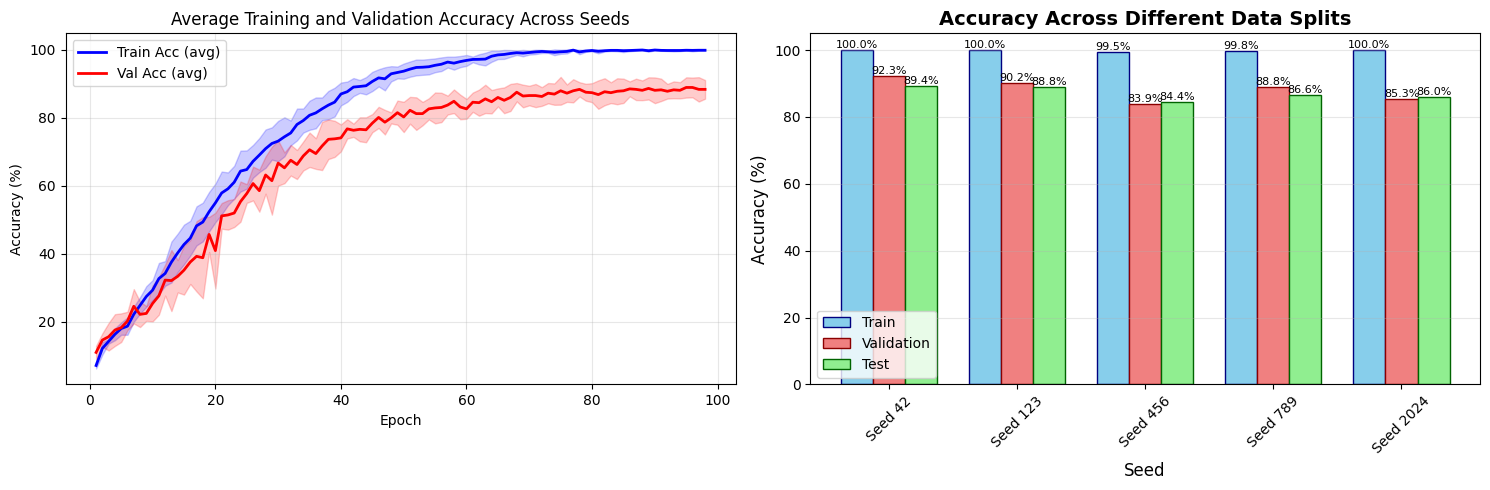

In [110]:
# --- Results summary ---
print("RESULTS SUMMARY")

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
print(f"\nAverage Test Accuracy: {np.mean(results['test_acc']):.2f}% ± {np.std(results['test_acc']):.2f}%")
print(f"Average Test Loss: {np.mean(results['test_loss']):.4f} ± {np.std(results['test_loss']):.4f}")

# Find best and worst seeds
best_seed = results_df.loc[results_df['test_acc'].idxmax(), 'seed']
worst_seed = results_df.loc[results_df['test_acc'].idxmin(), 'seed']
print(f"\nBest Seed: {best_seed} (Test Acc: {results_df[results_df['seed']==best_seed]['test_acc'].values[0]:.2f}%)")
print(f"Worst Seed: {worst_seed} (Test Acc: {results_df[results_df['seed']==worst_seed]['test_acc'].values[0]:.2f}%)")

# --- Plotting ---
print("GENERATING PLOTS")

# Plot 1: Average Training Curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Find minimum number of epochs across all runs
min_len = min(len(hist) for hist in all_train_histories)

# Truncate all histories to the same length
train_histories_aligned = [hist[:min_len] for hist in all_train_histories]
val_histories_aligned = [hist[:min_len] for hist in all_val_histories]

avg_train_acc = np.mean(train_histories_aligned, axis=0)
std_train_acc = np.std(train_histories_aligned, axis=0)
avg_val_acc = np.mean(val_histories_aligned, axis=0)
std_val_acc = np.std(val_histories_aligned, axis=0)

epochs_range = range(1, min_len + 1)

axes[0].plot(epochs_range, avg_train_acc, 'b-', label='Train Acc (avg)', linewidth=2)
axes[0].fill_between(epochs_range, 
                      np.array(avg_train_acc) - np.array(std_train_acc),
                      np.array(avg_train_acc) + np.array(std_train_acc),
                      alpha=0.2, color='b')
axes[0].plot(epochs_range, avg_val_acc, 'r-', label='Val Acc (avg)', linewidth=2)
axes[0].fill_between(epochs_range,
                      np.array(avg_val_acc) - np.array(std_val_acc),
                      np.array(avg_val_acc) + np.array(std_val_acc),
                      alpha=0.2, color='r')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Average Training and Validation Accuracy Across Seeds')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Test Accuracy by Seed
ax = axes[1]

x = np.arange(len(seeds))
width = 0.25

# Extract accuracies from all_results or compute from models_dict if needed
# Assuming you have lists of train and val accuracies per seed in `all_train_histories` and `all_val_histories`
# We'll take the final epoch accuracy for each seed
train_accs = [hist[-1] for hist in all_train_histories]
val_accs = [hist[-1] for hist in all_val_histories]
test_accs = results['test_acc']

# Plot bars
bars1 = ax.bar(x - width, train_accs, width, label='Train', color='skyblue', edgecolor='navy')
bars2 = ax.bar(x, val_accs, width, label='Validation', color='lightcoral', edgecolor='darkred')
bars3 = ax.bar(x + width, test_accs, width, label='Test', color='lightgreen', edgecolor='darkgreen')

# Labels and title
ax.set_xlabel('Seed', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Accuracy Across Different Data Splits', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'Seed {s}' for s in seeds], rotation=45)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('tcn_training_results_multi.png', dpi=300, bbox_inches='tight')
plt.show()


CONFUSION MATRICES


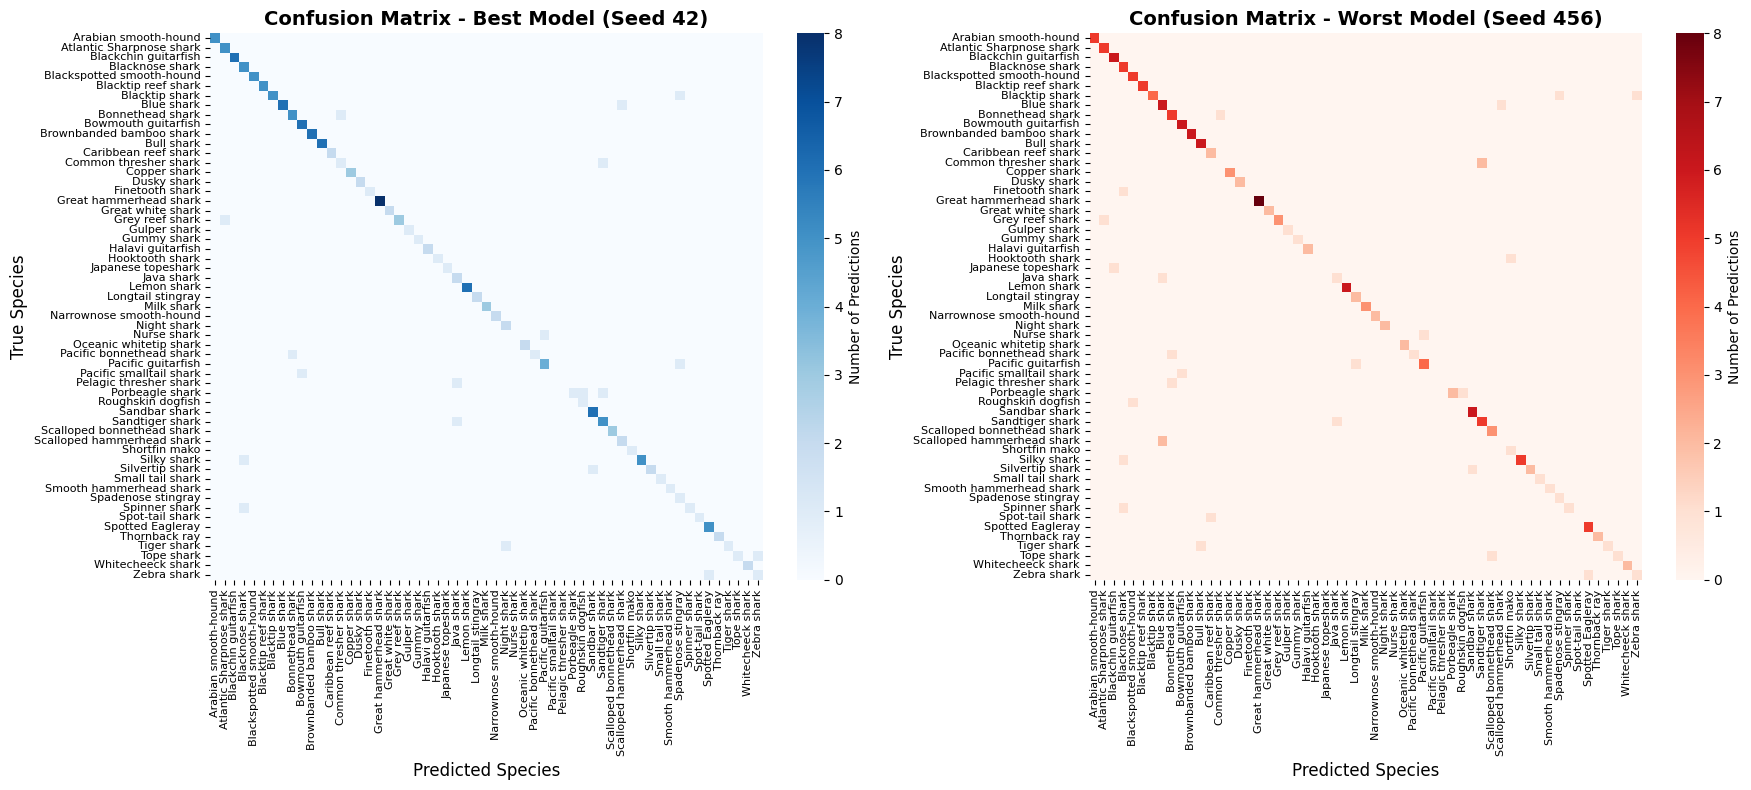

Confusion matrices saved as 'tcn_confusion_matrices.png'


In [106]:
# --- Confusion matrices for best and worst seeds ---
print("CONFUSION MATRICES")

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- Best Seed Confusion Matrix ---
cm_best = confusion_matrix(models_dict[best_seed]['test_labels'], 
                           models_dict[best_seed]['test_preds'])
sns.heatmap(cm_best, annot=False, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            ax=axes[0],
            cbar_kws={'label': 'Number of Predictions'})
axes[0].set_xlabel('Predicted Species', fontsize=12)
axes[0].set_ylabel('True Species', fontsize=12)
axes[0].set_title(f'Confusion Matrix - Best Model (Seed {best_seed})', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=90, labelsize=8)
axes[0].tick_params(axis='y', rotation=0, labelsize=8)

# --- Worst Seed Confusion Matrix ---
cm_worst = confusion_matrix(models_dict[worst_seed]['test_labels'], 
                            models_dict[worst_seed]['test_preds'])
sns.heatmap(cm_worst, annot=False, fmt='d', cmap='Reds',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            ax=axes[1],
            cbar_kws={'label': 'Number of Predictions'})
axes[1].set_xlabel('Predicted Species', fontsize=12)
axes[1].set_ylabel('True Species', fontsize=12)
axes[1].set_title(f'Confusion Matrix - Worst Model (Seed {worst_seed})', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=90, labelsize=8)
axes[1].tick_params(axis='y', rotation=0, labelsize=8)

plt.tight_layout()
plt.savefig('tcn_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print("Confusion matrices saved as 'tcn_confusion_matrices.png'")

In [104]:
# --- Classification Reports ---
print(f"CLASSIFICATION REPORT - BEST SEED ({best_seed})")
print(classification_report(models_dict[best_seed]['test_labels'],
                          models_dict[best_seed]['test_preds'],
                          target_names=label_encoder.classes_))

print("\n" + "=" * 80)
print(f"CLASSIFICATION REPORT - WORST SEED ({worst_seed})")
print("=" * 80)
print(classification_report(models_dict[worst_seed]['test_labels'],
                          models_dict[worst_seed]['test_preds'],
                          target_names=label_encoder.classes_))

CLASSIFICATION REPORT - BEST SEED (42)
                            precision    recall  f1-score   support

      Arabian smooth-hound       1.00      1.00      1.00         5
  Atlantic Sharpnose shark       0.83      1.00      0.91         5
      Blackchin guitarfish       1.00      1.00      1.00         6
           Blacknose shark       0.71      1.00      0.83         5
 Blackspotted smooth-hound       1.00      1.00      1.00         5
       Blacktip reef shark       1.00      1.00      1.00         5
            Blacktip shark       1.00      0.83      0.91         6
                Blue shark       1.00      0.86      0.92         7
          Bonnethead shark       0.83      0.83      0.83         6
       Bowmouth guitarfish       0.86      1.00      0.92         6
  Brownbanded bamboo shark       1.00      1.00      1.00         6
                Bull shark       1.00      1.00      1.00         6
      Caribbean reef shark       1.00      1.00      1.00         2
     Com